# Week 3, Day 4 — PyTorch Training Loop

**Goal:** Train a small classifier and plot how its loss changes during training.

This notebook demonstrates the five essential training-loop actions:

1. **Forward pass** — the model makes predictions.
2. **Loss calculation** — measure how wrong the predictions are.
3. **`optimizer.zero_grad()`** — clear gradients from the previous iteration.
4. **`loss.backward()`** — calculate new gradients using backpropagation.
5. **`optimizer.step()`** — update the model's weights.


In [1]:
# If this import fails, activate your project environment and install requirements:
# pip install -r project_02_transformer_lab/requirements.txt

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("Device: CPU")


PyTorch version: 2.11.0+cpu
Device: CPU


## 1. Create a simple classification dataset

Each example has two input features. The label is:

- `0` when the two features add to a value at or below zero
- `1` when their sum is greater than zero

The classifier must learn this boundary from examples.


In [2]:
torch.manual_seed(42)

X = torch.randn(200, 2)
y = (X[:, 0] + X[:, 1] > 0).long()

print("Input shape:", X.shape)
print("Label shape:", y.shape)
print("First five inputs:\n", X[:5])
print("First five labels:", y[:5])


Input shape: torch.Size([200, 2])
Label shape: torch.Size([200])
First five inputs:
 tensor([[ 1.9269,  1.4873],
        [ 0.9007, -2.1055],
        [ 0.6784, -1.2345],
        [-0.0431, -1.6047],
        [-0.7521,  1.6487]])
First five labels: tensor([1, 0, 0, 0, 1])


## 2. Separate training and test data

The model learns from the first 160 examples. The remaining 40 examples are kept unseen during training and used for evaluation.


In [3]:
X_train, X_test = X[:160], X[160:]
y_train, y_test = y[:160], y[160:]

print("Training examples:", len(X_train))
print("Test examples:", len(X_test))


Training examples: 160
Test examples: 40


## 3. Define the classifier

The network transforms two input values into eight hidden values and then produces two output scores called **logits**—one score for each class.


In [4]:
class TwoLayerClassifier(nn.Module):
    def __init__(self, input_size=2, hidden_size=8, num_classes=2):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        return self.fc2(x)


model = TwoLayerClassifier()
print(model)


TwoLayerClassifier(
  (fc1): Linear(in_features=2, out_features=8, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=8, out_features=2, bias=True)
)


## 4. Choose the loss function and optimizer

- **Cross-entropy loss** compares the two output logits with the correct class labels.
- **Adam optimizer** changes the model parameters to reduce the loss.
- The **learning rate** (`lr=0.01`) controls the size of each update.


In [5]:
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


## 5. Train the classifier

One **epoch** means one complete pass through the training data.

Pay attention to the order inside the loop:

```text
clear old gradients → forward pass → calculate loss → backward pass → update weights
```


In [6]:
epochs = 200
loss_history = []

for epoch in range(epochs):
    # 1. Clear gradients saved during the previous epoch.
    optimizer.zero_grad()

    # 2. Forward pass: produce class scores (logits).
    logits = model(X_train)

    # 3. Compare predictions with the correct labels.
    loss = loss_function(logits, y_train)

    # 4. Backward pass: calculate a gradient for every trainable parameter.
    loss.backward()

    # 5. Use those gradients to update the model's parameters.
    optimizer.step()

    loss_history.append(loss.item())

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1:3d}/{epochs} | Loss: {loss.item():.4f}")


Epoch  20/200 | Loss: 0.4723
Epoch  40/200 | Loss: 0.2343
Epoch  60/200 | Loss: 0.1306
Epoch  80/200 | Loss: 0.0914
Epoch 100/200 | Loss: 0.0724
Epoch 120/200 | Loss: 0.0597
Epoch 140/200 | Loss: 0.0507
Epoch 160/200 | Loss: 0.0436
Epoch 180/200 | Loss: 0.0379
Epoch 200/200 | Loss: 0.0333


### What exactly happened in one epoch?

| Code | Meaning |
|---|---|
| `optimizer.zero_grad()` | Removes gradients left from the previous epoch |
| `logits = model(X_train)` | Performs the forward pass |
| `loss = loss_function(logits, y_train)` | Measures prediction error |
| `loss.backward()` | Computes how each parameter contributed to the error |
| `optimizer.step()` | Changes parameters in the direction that should reduce error |

PyTorch adds gradients together by default. That is why `zero_grad()` is required before calculating the next set of gradients.


## 6. Plot the training loss

A generally decreasing loss indicates that the model is learning the training pattern.


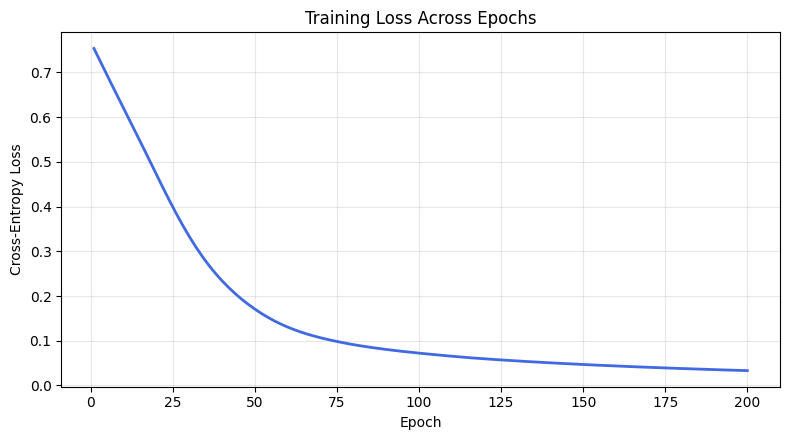

In [7]:
plt.figure(figsize=(8, 4.5))
plt.plot(range(1, epochs + 1), loss_history, color="royalblue", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss Across Epochs")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Evaluate the trained classifier

Evaluation does not require gradients, so it is performed inside `torch.no_grad()`. `model.eval()` switches the model to evaluation mode.


In [8]:
model.eval()

with torch.no_grad():
    test_logits = model(X_test)
    test_predictions = torch.argmax(test_logits, dim=1)
    test_accuracy = (test_predictions == y_test).float().mean()

print(f"Final training loss: {loss_history[-1]:.4f}")
print(f"Test accuracy: {test_accuracy.item():.3f}")
print("First 10 predictions:", test_predictions[:10].tolist())
print("First 10 true labels:", y_test[:10].tolist())


Final training loss: 0.0333
Test accuracy: 0.975
First 10 predictions: [0, 0, 1, 1, 1, 0, 1, 0, 1, 1]
First 10 true labels: [0, 0, 1, 1, 1, 0, 1, 0, 1, 1]


## 8. Verify the result

These assertions confirm that training completed, the loss stayed finite, and the classifier learned substantially better than random guessing.


In [9]:
assert len(loss_history) == epochs
assert torch.isfinite(torch.tensor(loss_history)).all()
assert loss_history[-1] < loss_history[0]
assert test_accuracy.item() >= 0.80

print("Day 4 training-loop checks passed successfully!")


Day 4 training-loop checks passed successfully!


## Key takeaway

The training loop repeatedly makes predictions, measures error, calculates gradients, and updates parameters. The loss curve lets us see whether those updates are helping the model learn.
